# AppStat Chapter 4: k-NN regression with LOOCV-selected \(k\)

This notebook is for teaching purposes. It reproduces the numerical results used in the Chapter 4 slides. The cholestyramine data are from Table 7.4 of Efron and Tibshirani (1993).

The notebook replaces LOESS by ordinary \(k\)-nearest-neighbour regression. The value of \(k\) is selected by leave-one-out cross-validation (LOOCV).

The fast LOOCV identity for \(k\)-NN regression follows Kanagawa (2024), *Transactions on Machine Learning Research*. Under the tie-breaking rule used below, the LOOCV mean squared error for \(k\)-NN regression equals the training mean squared error of \((k+1)\)-NN regression, multiplied by \((k+1)^2/k^2\).

After selecting \(k\) from the original data, the bootstrap keeps this same \(k\) fixed. If \(k\) were reselected inside each bootstrap sample, the bootstrap would describe the variability of a different procedure.

This is teaching code, not polished research software.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

rng = np.random.default_rng(20260429)
output_dir = Path("appstat_ch4_knn_figures")
output_dir.mkdir(exist_ok=True)
output_dir

PosixPath('appstat_ch4_knn_figures')

## 1. Exact cholestyramine data

The notebook first tries to read `ch4_cholestyramine_exact_table74.csv` from the working directory.  
This is the preferred format for sharing with students.

A compact embedded CSV is kept only as a fallback, in case the external CSV file is missing.


In [2]:
from io import StringIO

csv_path = Path("ch4_cholestyramine_exact_table74.csv")

fallback_csv = """compliance,improvement
0,-5.25
0,-7.25
0,-6.25
0,11.5
2,21.0
2,-23.0
2,5.75
3,3.25
3,8.75
4,8.25
4,-10.25
7,-10.5
8,19.75
8,-0.5
8,29.25
8,36.25
9,10.75
9,19.5
9,17.25
10,3.5
10,11.25
11,-13.0
12,24.0
13,2.5
15,3.0
15,5.5
16,21.25
16,29.75
17,7.5
18,-16.5
20,4.5
20,39.0
21,-5.75
21,-21.0
21,0.25
22,-10.25
24,-0.5
25,-19.0
25,15.75
26,6.0
27,10.5
27,-1.5
28,23.5
29,33.0
31,4.25
32,18.75
32,8.5
33,3.25
33,27.75
34,30.75
34,-1.5
34,1.0
34,7.75
35,-15.75
36,33.5
36,36.25
37,5.5
38,25.5
41,20.25
43,33.25
45,56.75
45,4.25
47,32.5
50,54.5
50,-4.25
51,42.75
51,62.75
52,64.25
53,30.25
54,14.75
54,47.25
56,18.0
57,13.75
57,48.75
58,43.0
60,27.75
62,44.5
64,22.5
64,-14.5
64,-20.75
67,46.25
68,39.5
71,59.5
71,14.75
72,63.0
72,0.0
73,42.0
74,41.25
75,36.25
76,66.5
77,61.75
77,14.0
78,36.0
78,39.5
81,1.0
82,53.5
84,46.5
85,51.0
85,39.0
87,-0.25
87,1.0
87,46.75
87,11.5
87,2.75
88,48.75
89,56.75
90,29.25
90,72.5
91,41.75
92,48.5
92,61.25
92,29.5
92,59.75
93,71.0
93,37.75
93,41.0
93,9.75
93,53.75
94,62.5
94,39.0
94,3.25
94,60.0
95,113.25
95,32.5
95,70.75
95,18.25
95,76.0
95,75.75
95,78.75
95,54.75
95,77.0
96,68.0
96,73.0
96,28.75
96,26.75
96,56.0
96,47.5
96,30.25
96,21.0
97,79.0
97,69.0
97,80.0
97,86.0
98,54.75
98,26.75
98,80.0
98,42.25
98,6.0
98,104.75
98,94.25
98,41.25
98,40.25
99,51.5
99,82.75
99,85.0
99,70.0
100,92.0
100,73.75
100,54.0
100,69.5
100,101.5
100,68.0
100,44.75
100,86.75
"""

if csv_path.exists():
    df = pd.read_csv(csv_path)
    data_source = f"Loaded external CSV: {csv_path}"
else:
    df = pd.read_csv(StringIO(fallback_csv))
    data_source = "Used embedded fallback CSV."

print(data_source)
display(df.head())
print(f"n = {len(df)}")


Used embedded fallback CSV.


,compliance,improvement
0,0,-5.25
1,0,-7.25
2,0,-6.25
3,0,11.50
4,2,21.00


n = 164


In [3]:
z = df["compliance"].to_numpy(dtype=float)
y = df["improvement"].to_numpy(dtype=float)
n = len(z)

print(f"n = {n}")
print(f"number of distinct compliance values = {len(np.unique(z))}")
print(f"compliance range = [{z.min()}, {z.max()}]")
print(f"improvement range = [{y.min()}, {y.max()}]")

n = 164
number of distinct compliance values = 75
compliance range = [0.0, 100.0]
improvement range = [-23.0, 113.25]


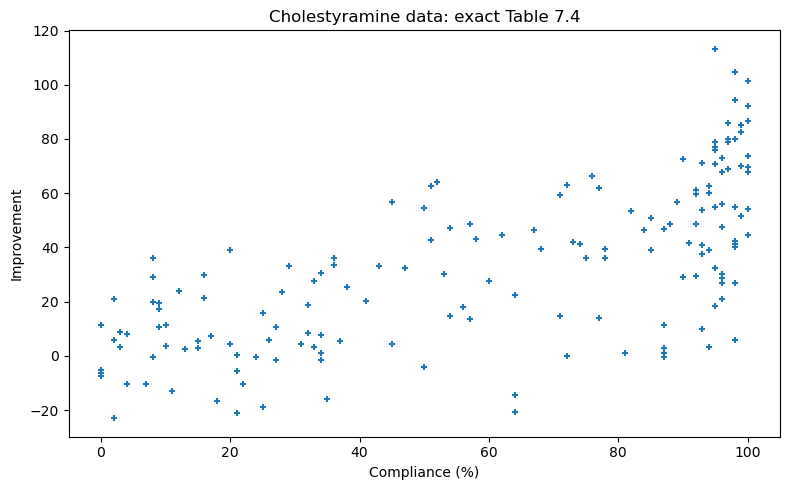

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(z, y, s=18, marker="+")
plt.xlabel("Compliance (%)")
plt.ylabel("Improvement")
plt.title("Cholestyramine data: exact Table 7.4")
plt.tight_layout()
plt.savefig(output_dir / "ch4_cholestyramine_scatter.png", dpi=180)
plt.show()

## 2. \(k\)-NN regression and fast LOOCV

For a new input \(z_0\), ordinary \(k\)-NN regression averages the responses attached to the \(k\) nearest observed compliance values.

Let \(\widehat r_k\) denote the \(k\)-NN regression estimate using all training data.  
For observation \(i\), let \(\widehat r_k^{(-i)}\) denote the same estimate after removing the pair \((z_i,y_i)\) from the training data.

The direct LOOCV score is
\[
\operatorname{LOOCV}(k)
=
\frac{1}{n}\sum_{i=1}^n
\{y_i-\widehat r_k^{(-i)}(z_i)\}^2.
\]

A direct implementation refits the method \(n\) times for each \(k\). For \(k\)-NN regression this is unnecessary. With the deterministic tie-breaking rule used below,
\[
\operatorname{LOOCV}(k)
=
\frac{(k+1)^2}{k^2}\,
\frac{1}{n}\sum_{i=1}^n
\{y_i-\widehat r_{k+1}(z_i)\}^2.
\]

Here \(\widehat r_{k+1}(z_i)\) is computed on the full training sample and includes observation \(i\) itself.  
This is the fast computation method used below.

Because the compliance values contain ties, the implementation fixes a deterministic tie-breaking rule. For the training-point calculation, observation \(i\) is placed first among points tied at distance zero. This makes the fast score agree with direct LOOCV for the implemented rule.


In [5]:
def knn_predict(z_train, y_train, z_eval, k):
    """Ordinary unweighted k-NN regression in one dimension.

    Ties are broken deterministically by the original row index.
    """
    z_train = np.asarray(z_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    z_eval = np.atleast_1d(np.asarray(z_eval, dtype=float))
    n_train = len(z_train)
    if not (1 <= k <= n_train):
        raise ValueError(f"k must satisfy 1 <= k <= n_train; got k={k}, n_train={n_train}.")

    preds = np.empty(len(z_eval))
    row_index = np.arange(n_train)
    for j, zz in enumerate(z_eval):
        order = np.lexsort((row_index, np.abs(z_train - zz)))
        preds[j] = np.mean(y_train[order[:k]])
    return preds


def knn_training_predict_include_self_first(z_train, y_train, K):
    """Training predictions for K-NN, with the target observation included first.

    This is used for the fast LOOCV identity with K = k + 1.
    """
    z_train = np.asarray(z_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    n_train = len(z_train)
    if not (1 <= K <= n_train):
        raise ValueError(f"K must satisfy 1 <= K <= n_train; got K={K}, n_train={n_train}.")

    preds = np.empty(n_train)
    for i in range(n_train):
        others = [j for j in range(n_train) if j != i]
        others.sort(key=lambda j: (abs(z_train[j] - z_train[i]), j))
        neighbours = [i] + others[:K - 1]
        preds[i] = np.mean(y_train[neighbours])
    return preds


def fast_loocv_score(z_train, y_train, k):
    """Fast LOOCV MSE for k-NN regression."""
    pred_k_plus_1 = knn_training_predict_include_self_first(z_train, y_train, K=k + 1)
    training_mse = np.mean((y_train - pred_k_plus_1) ** 2)
    return ((k + 1) ** 2 / k ** 2) * training_mse


def direct_loocv_score(z_train, y_train, k):
    """Direct LOOCV MSE for checking the fast identity."""
    z_train = np.asarray(z_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    n_train = len(z_train)
    preds = np.empty(n_train)
    for i in range(n_train):
        others = [j for j in range(n_train) if j != i]
        others.sort(key=lambda j: (abs(z_train[j] - z_train[i]), j))
        neighbours = others[:k]
        preds[i] = np.mean(y_train[neighbours])
    return np.mean((y_train - preds) ** 2)


In [6]:
k_grid = np.arange(1, n)  # k = 1, ..., n - 1
cv_scores = np.array([fast_loocv_score(z, y, int(k)) for k in k_grid])
k_selected = int(k_grid[np.argmin(cv_scores)])
cv_min = float(cv_scores.min())

print(f"Selected k by fast LOOCV: k = {k_selected}")
print(f"Minimum LOOCV MSE: {cv_min:.3f}")

# Check equality with direct LOOCV for a few values, including the selected k.
check_ks = [1, 2, 5, 10, k_selected, 50, 100, n - 1]
check = []
for k in check_ks:
    if 1 <= k < n:
        f = fast_loocv_score(z, y, k)
        d = direct_loocv_score(z, y, k)
        check.append({"k": k, "fast_LOOCV": f, "direct_LOOCV": d, "difference": f - d})

pd.DataFrame(check)

Selected k by fast LOOCV: k = 29
Minimum LOOCV MSE: 474.862


,k,fast_LOOCV,direct_LOOCV,difference
0,1,950.154345,950.154345,0.000000e+00
1,2,618.664920,618.664920,0.000000e+00
2,5,526.568674,526.568674,2.273737e-13
3,10,486.147382,486.147382,-5.684342e-14
4,29,474.861592,474.861592,1.136868e-13
5,50,483.967889,483.967889,0.000000e+00
6,100,583.777976,583.777976,1.136868e-13
7,163,905.838842,905.838842,-1.136868e-13


In [7]:
top = pd.DataFrame({"k": k_grid, "LOOCV_MSE": cv_scores}).sort_values("LOOCV_MSE").head(15)
top

,k,LOOCV_MSE
28,29,474.861592
17,18,476.811507
13,14,477.970786
45,46,478.527044
25,26,479.733915
30,31,479.886576
27,28,480.056419
44,45,480.461775
29,30,480.559719
26,27,480.675635


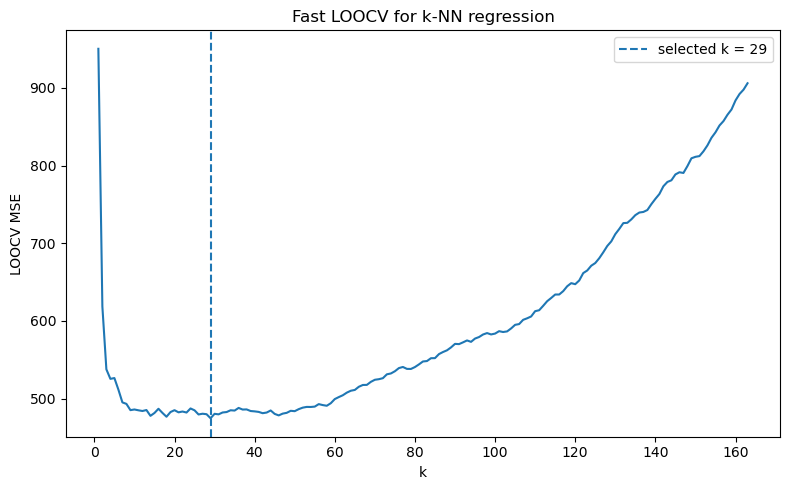

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_grid, cv_scores, linewidth=1.5)
plt.axvline(k_selected, linestyle="--", linewidth=1.5, label=f"selected k = {k_selected}")
plt.xlabel("k")
plt.ylabel("LOOCV MSE")
plt.title("Fast LOOCV for k-NN regression")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "ch4_knn_loocv_curve.png", dpi=180)
plt.show()

## 3. Quadratic fit and selected \(k\)-NN fit

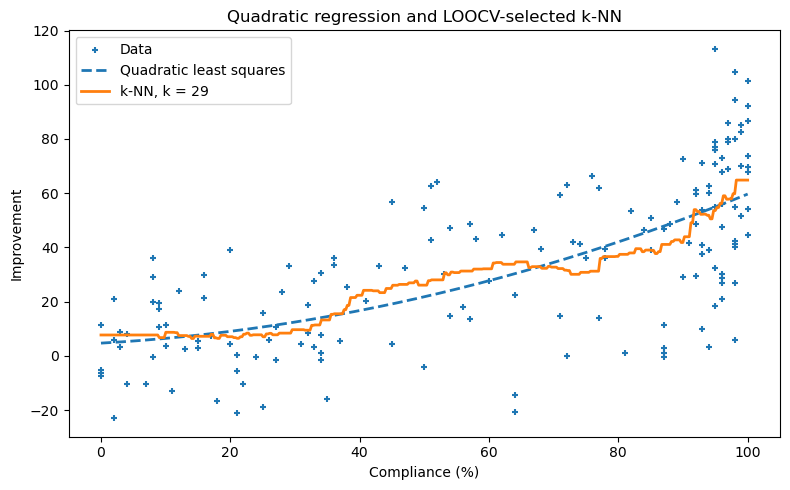

In [9]:
def quadratic_predict(z_train, y_train, z_eval):
    coef = np.polyfit(z_train, y_train, deg=2)
    return np.polyval(coef, np.asarray(z_eval, dtype=float))

z_grid = np.linspace(0, 100, 400)
y_quad_grid = quadratic_predict(z, y, z_grid)
y_knn_grid = knn_predict(z, y, z_grid, k_selected)

plt.figure(figsize=(8, 5))
plt.scatter(z, y, s=16, marker="+", label="Data")
plt.plot(z_grid, y_quad_grid, linestyle="--", linewidth=2, label="Quadratic least squares")
plt.plot(z_grid, y_knn_grid, linewidth=2, label=f"k-NN, k = {k_selected}")
plt.xlabel("Compliance (%)")
plt.ylabel("Improvement")
plt.title("Quadratic regression and LOOCV-selected k-NN")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "ch4_regression_curves_knn.png", dpi=180)
plt.show()

In [10]:
selected_points = np.array([60, 80, 100], dtype=float)
quad_point = quadratic_predict(z, y, selected_points)
knn_point = knn_predict(z, y, selected_points, k_selected)

point_table = pd.DataFrame({
    "z0": selected_points,
    "quadratic_fit": quad_point,
    f"knn_fit_k_{k_selected}": knn_point,
})
point_table

,z0,quadratic_fit,knn_fit_k_29
0,60.0,27.715436,32.112069
1,80.0,42.032434,36.698276
2,100.0,59.672770,64.836207


## 4. Bootstrap with fixed selected \(k\)

We select \(k\) once using the original data. In the bootstrap experiment below, this selected \(k\) is kept fixed.

Each bootstrap sample is formed by resampling the observed pairs \((z_i,y_i)\) with replacement. The quadratic regression and the \(k\)-NN regression with the selected \(k\) are then refitted on each bootstrap sample.

This convention estimates the sampling variability of the fitted regression method with the chosen value of \(k\). It does not include the extra variability from reselecting \(k\).


In [11]:
def bootstrap_regression_curves(z, y, k, B=50, seed=20260429):
    rng = np.random.default_rng(seed)
    n = len(z)
    z_grid = np.linspace(0, 100, 400)
    points = np.array([60, 80, 100], dtype=float)

    quad_curves = []
    knn_curves = []
    quad_values = []
    knn_values = []

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        zb = z[idx]
        yb = y[idx]

        quad_curves.append(quadratic_predict(zb, yb, z_grid))
        knn_curves.append(knn_predict(zb, yb, z_grid, k))
        quad_values.append(quadratic_predict(zb, yb, points))
        knn_values.append(knn_predict(zb, yb, points, k))

    return {
        "z_grid": z_grid,
        "points": points,
        "quad_curves": np.asarray(quad_curves),
        "knn_curves": np.asarray(knn_curves),
        "quad_values": np.asarray(quad_values),
        "knn_values": np.asarray(knn_values),
    }

B_BOOT = 50
boot = bootstrap_regression_curves(z, y, k_selected, B=B_BOOT, seed=20260429)

quad_se = boot["quad_values"].std(axis=0, ddof=1)
knn_se = boot["knn_values"].std(axis=0, ddof=1)

bootstrap_table = pd.DataFrame({
    "z0": boot["points"],
    "quadratic_value": quad_point,
    "quadratic_boot_se": quad_se,
    f"knn_value_k_{k_selected}": knn_point,
    f"knn_boot_se_k_{k_selected}": knn_se,
})
bootstrap_table

,z0,quadratic_value,quadratic_boot_se,knn_value_k_29,knn_boot_se_k_29
0,60.0,27.715436,2.908910,32.112069,4.556544
1,80.0,42.032434,2.015806,36.698276,4.391000
2,100.0,59.672770,3.283044,64.836207,4.572160


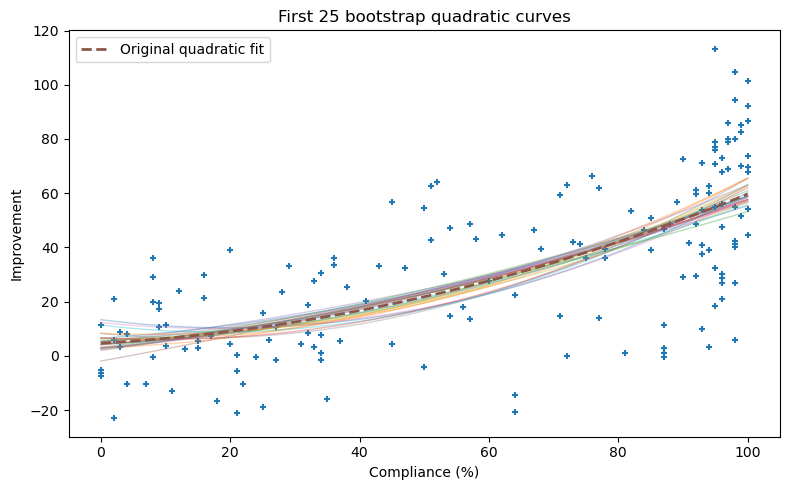

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(z, y, s=14, marker="+")
for curve in boot["quad_curves"][:25]:
    plt.plot(boot["z_grid"], curve, alpha=0.35, linewidth=1)
plt.plot(z_grid, y_quad_grid, linestyle="--", linewidth=2, label="Original quadratic fit")
plt.xlabel("Compliance (%)")
plt.ylabel("Improvement")
plt.title("First 25 bootstrap quadratic curves")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "ch4_bootstrap_quad_curves.png", dpi=180)
plt.show()

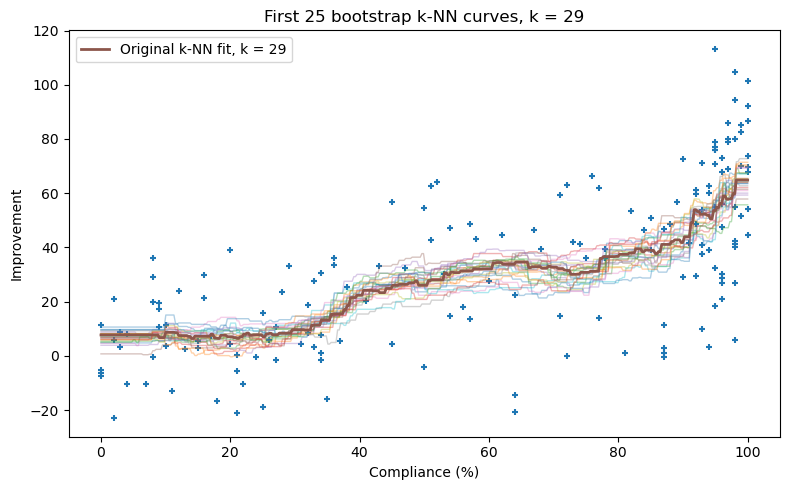

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(z, y, s=14, marker="+")
for curve in boot["knn_curves"][:25]:
    plt.plot(boot["z_grid"], curve, alpha=0.35, linewidth=1)
plt.plot(z_grid, y_knn_grid, linewidth=2, label=f"Original k-NN fit, k = {k_selected}")
plt.xlabel("Compliance (%)")
plt.ylabel("Improvement")
plt.title(f"First 25 bootstrap k-NN curves, k = {k_selected}")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "ch4_bootstrap_knn_curves.png", dpi=180)
plt.show()

## 5. Slope-difference statistic for selected \(k\)-NN

For the selected \(k\)-NN fit, define
\[
\widehat\theta
=
\frac{\widehat r_{k\mathrm{NN}}(100)-\widehat r_{k\mathrm{NN}}(80)}{20}
-
\frac{\widehat r_{k\mathrm{NN}}(80)-\widehat r_{k\mathrm{NN}}(60)}{20}.
\]
The same statistic is computed for each bootstrap sample, with the same selected \(k\).


In [14]:
def slope_difference(values_60_80_100):
    values = np.asarray(values_60_80_100, dtype=float)
    return (values[..., 2] - values[..., 1]) / 20 - (values[..., 1] - values[..., 0]) / 20

theta_hat_knn = float(slope_difference(knn_point))
theta_star_knn = slope_difference(boot["knn_values"])

theta_summary = pd.DataFrame({
    "quantity": ["theta_hat", "bootstrap_mean", "bootstrap_sd", "bootstrap_min", "bootstrap_median", "bootstrap_max", "proportion_positive"],
    "value": [
        theta_hat_knn,
        theta_star_knn.mean(),
        theta_star_knn.std(ddof=1),
        theta_star_knn.min(),
        np.median(theta_star_knn),
        theta_star_knn.max(),
        np.mean(theta_star_knn > 0),
    ]
})
theta_summary

,quantity,value
0,theta_hat,1.177586
1,bootstrap_mean,1.214431
2,bootstrap_sd,0.594458
3,bootstrap_min,-0.317241
4,bootstrap_median,1.288578
5,bootstrap_max,2.510776
6,proportion_positive,0.980000


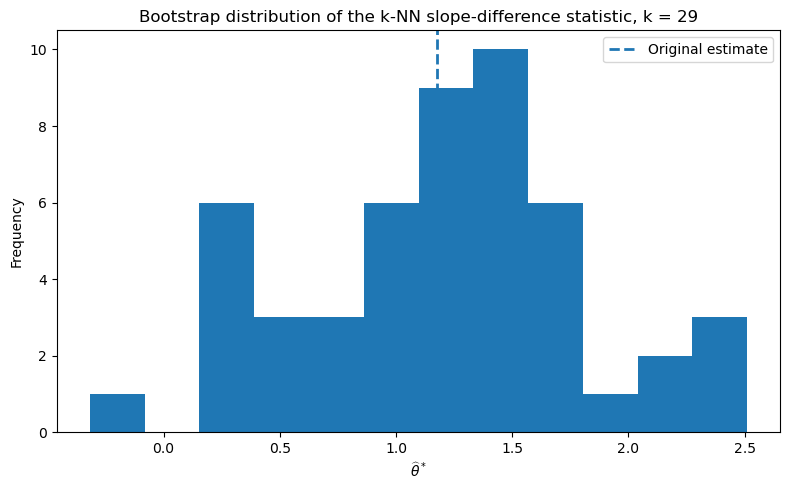

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(theta_star_knn, bins=12)
plt.axvline(theta_hat_knn, linestyle="--", linewidth=2, label="Original estimate")
plt.xlabel(r"$\widehat\theta^*$")
plt.ylabel("Frequency")
plt.title(f"Bootstrap distribution of the k-NN slope-difference statistic, k = {k_selected}")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "ch4_knn_slope_bootstrap_hist.png", dpi=180)
plt.show()

## 6. Optional: Monte Carlo stability check

The slides use \(B=50\), following the scale used in Efron and Tibshirani's example.

The next cell repeats the bootstrap with \(B=1000\). This is only a Monte Carlo stability check for the numerical summaries. The selected \(k\) is still kept fixed.


In [16]:
B_STABLE = 1000
boot_stable = bootstrap_regression_curves(z, y, k_selected, B=B_STABLE, seed=20260429)

theta_star_stable = slope_difference(boot_stable["knn_values"])

stable_table = pd.DataFrame({
    "z0": boot_stable["points"],
    f"knn_value_k_{k_selected}": knn_point,
    f"knn_boot_se_B_{B_STABLE}": boot_stable["knn_values"].std(axis=0, ddof=1),
})

stable_theta_summary = pd.DataFrame({
    "quantity": ["theta_hat", "bootstrap_mean", "bootstrap_sd", "bootstrap_2.5%", "bootstrap_50%", "bootstrap_97.5%", "proportion_positive"],
    "value": [
        theta_hat_knn,
        theta_star_stable.mean(),
        theta_star_stable.std(ddof=1),
        np.quantile(theta_star_stable, 0.025),
        np.quantile(theta_star_stable, 0.50),
        np.quantile(theta_star_stable, 0.975),
        np.mean(theta_star_stable > 0),
    ]
})

display(stable_table)
display(stable_theta_summary)

,z0,knn_value_k_29,knn_boot_se_B_1000
0,60.0,32.112069,4.470808
1,80.0,36.698276,4.111182
2,100.0,64.836207,4.877789


,quantity,value
0,theta_hat,1.177586
1,bootstrap_mean,1.129916
2,bootstrap_sd,0.496868
3,bootstrap_2.5%,0.200636
4,bootstrap_50%,1.112284
5,bootstrap_97.5%,2.135011
6,proportion_positive,0.989000


## 7. Files written

The figures are written to `appstat_ch4_knn_figures/`.

The main numerical results in this run are:

- selected \(k\) by fast LOOCV: \(k=29\);
- bootstrap uses this same \(k=29\) fixed across all bootstrap samples;
- \(B=50\) is used for the lecture-slide summaries;
- \(B=1000\) is included only as an optional Monte Carlo stability check.
